# 06 · Desempeño y contexto por estudiante — Microdatos APRENDER 2024

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/06_microdatos.ipynb)

Los notebooks 02 a 05 usan bases **agregadas**: no permiten cruzar el desempeño de cada estudiante con su contexto. Los
**microdatos 2024** sí (una sola foto, sin serie de tiempo):

| Base | Operativo | Estudiantes | Desempeño | Contexto |
|---|---|---|---|---|
| Secundaria | 5°/6° año, **censal** | 386.882 | Lengua y Matemática (puntaje y 4 niveles) | educación de la madre, libros, computadora, espacio para estudiar, baños, repitencia en primaria, horas de estudio, edad, sexo, sector, ámbito (**sin nivel socioeconómico**) |
| Primaria | 3° grado, **muestral** (alfabetización) | 91.264 | Lectura (puntaje y 6 niveles) | **nivel socioeconómico de la escuela**, jardín, repitencia, libros, celular, apoyo familiar, gusto por la escuela, vínculo con la maestra, lectura en casa, edad, sexo, sector |

**Qué hace (descriptivo, sin econometría):**
- **A · Secundaria:** % Satisfactorio + Avanzado, % por debajo del básico y puntaje medio según cada variable de contexto;
  un **conteo simple de recursos del hogar**; la brecha **estatal/privado a igual contexto**; y las **provincias a igual
  composición de los hogares** (estandarización directa por educación de la madre × libros).
- **B · Primaria 3°:** lo mismo para lectura, con el **nivel socioeconómico de la escuela** (NSE), cruces de jardín, libros y
  lectura en casa **dentro de cada NSE**, sector a igual NSE y provincias estandarizadas por NSE.

**Cómo leerlo:**
- Todos los porcentajes son **ponderados** (Secundaria: `ponderL` / `ponderM` para Lengua / Matemática y `ponder` para la
  distribución de contexto; Primaria: `ponderL` y `ponder`). Se excluyen respuestas vacías.
- Las bases están **anonimizadas**: ruido aleatorio en puntajes y ponderadores (no cambia medias ni niveles), categorías
  agrupadas y < 10 % de códigos de escuela reasignados. **No** se analizan escuelas individuales.
- Primaria es **muestral**: diferencias de 1–2 pp pueden ser ruido, sobre todo por provincia (se informa el *n*).
- **Asociación, no causa:** el contexto se superpone (hogares con más libros también tienen madres más educadas, etc.).

**Requisito:** subir a *Mi unidad/`pruebas_aprender`* los dos zip de la fuente oficial:
`2024 Base de microdatos Aprender primaria.zip` y `2024 Base de microdatos Aprender secundaria.zip`. No necesita el 00 ni
otros notebooks (solo el Drive montado).

---
## 0 · Setup y carga de los microdatos
En Colab: monta el Drive, busca los dos zip en *Mi unidad/`pruebas_aprender`*, extrae los `.sav` en `/content` e instala
`pyreadstat` si hace falta. En local usa `resultados_aprender/`.

In [1]:
import os, re, sys, glob, shutil, subprocess, textwrap, unicodedata, zipfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

try:
    import pyreadstat
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyreadstat'], check=True)
    import pyreadstat

def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/pruebas_aprender'
    EXTRAER = '/content/microdatos_2024'
else:
    CARPETA = os.path.join(os.getcwd(), 'resultados_aprender')
    EXTRAER = os.path.join(os.getcwd(), 'microdatos_2024_tmp')

def ubicar_sav(nivel):
    """Devuelve la ruta del .sav de `nivel` ('primaria' | 'secundaria'): lo extrae del zip si existe; si no, busca el .sav."""
    zips = [f for f in glob.glob(os.path.join(CARPETA, '*.zip')) if 'microdato' in _n(os.path.basename(f)) and nivel in _n(os.path.basename(f))]
    if zips:
        with zipfile.ZipFile(zips[0]) as zf:
            savs = [m for m in zf.namelist() if m.lower().endswith('.sav')]
            assert savs, f'El zip {os.path.basename(zips[0])} no tiene archivos .sav. Contenido: {zf.namelist()}'
            nombre = max(savs, key=lambda m: zf.getinfo(m).file_size)
            destino = os.path.join(EXTRAER, nivel)
            if not os.path.exists(os.path.join(destino, nombre)):
                zf.extract(nombre, destino)
            print(f'{nivel}: {os.path.basename(zips[0])} → {nombre} ({zf.getinfo(nombre).file_size / 1e6:.1f} MB)')
            return os.path.join(destino, nombre)
    patron = 'Base_publica_prim_Ap2024.sav' if nivel == 'primaria' else 'Base_publica_Ap2024.sav'
    ruta = os.path.join(CARPETA, patron)
    assert os.path.exists(ruta), (f'No encuentro el zip de microdatos de {nivel} en {CARPETA}. Subí '
                                  f'"2024 Base de microdatos Aprender {nivel}.zip" a Mi unidad/pruebas_aprender. '
                                  f'Zips encontrados: {[os.path.basename(z) for z in glob.glob(os.path.join(CARPETA, "*.zip"))]}')
    print(f'{nivel}: {ruta}')
    return ruta

def leer(nivel):
    df, meta = pyreadstat.read_sav(ubicar_sav(nivel), apply_value_formats=True)
    for c in df.columns:
        if df[c].dtype == object or str(df[c].dtype) == 'category':
            df[c] = df[c].astype('string').str.strip().replace({'': pd.NA})
    return df

SEC, PRI = leer('secundaria'), leer('primaria')
PROV = {'Ciudad Autónoma de Buenos Aires': 'CABA', 'Tierra del Fuego, Antártida e Islas del Atlántico Sur': 'Tierra del Fuego'}
for df in (SEC, PRI):
    df['provincia'] = df.jurisdiccion.replace(PROV)
print(f'\nSecundaria: {SEC.shape[0]:,} estudiantes × {SEC.shape[1]} columnas (referencia 386.882 × 22 + provincia)')
print(f'Primaria:   {PRI.shape[0]:,} estudiantes × {PRI.shape[1]} columnas (referencia 91.264 × 24 + provincia)')
for col in ['lpuntaje', 'mpuntaje', 'ldesemp', 'mdesemp', 'Nivel_Ed_MadreX', 'ap19X', 'ap16g', 'ponderL', 'ponderM']:
    assert col in SEC.columns, f'Falta la columna {col} en Secundaria'
for col in ['lpuntaje', 'ldesemp', 'NSE_escuela', 'Jardin', 'Libros', 'ponderL']:
    assert col in PRI.columns, f'Falta la columna {col} en Primaria'

# Paleta validada: azul / naranja / aqua (categórica, en ese orden), azul/rojo divergente
SUPERFICIE, TINTA, TINTA_2, TENUE, GRILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, AQUA, ROJO, NEUTRO = '#2a78d6', '#eb6834', '#1baf7a', '#e34948', '#f0efec'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'text.color': TINTA, 'axes.labelcolor': TINTA_2, 'axes.edgecolor': EJE, 'axes.titlecolor': TINTA,
    'xtick.color': TENUE, 'ytick.color': TINTA_2, 'axes.grid': True, 'grid.color': GRILLA, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})
GRAF = os.path.abspath('graficos_microdatos'); os.makedirs(GRAF, exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(os.path.join(GRAF, nombre + '.png'), dpi=300, bbox_inches='tight')
    return fig
def nota(fig, texto, y=-0.01):
    fig.text(0.01, y, texto, fontsize=8, color=TENUE, ha='left', va='top')
FUENTE_S = 'Fuente: microdatos APRENDER 2024, Secundaria 5°/6° año (censal, anonimizada). % ponderados.'
FUENTE_P = 'Fuente: microdatos APRENDER 2024, Primaria 3° grado (muestral, anonimizada). % ponderados.'
print('Salidas (gráficos 300 dpi + Excel) en:', GRAF)

secundaria: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\resultados_aprender\Base_publica_Ap2024.sav


primaria: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\resultados_aprender\Base_publica_prim_Ap2024.sav



Secundaria: 386,882 estudiantes × 23 columnas (referencia 386.882 × 22 + provincia)
Primaria:   91,264 estudiantes × 25 columnas (referencia 91.264 × 24 + provincia)
Salidas (gráficos 300 dpi + Excel) en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_microdatos


---
## 1 · Funciones y control contra las bases agregadas
Antes de analizar, se verifica que los % ponderados reproduzcan los resultados publicados / agregados (control hecho en
la exploración del 2026-09-14): Secundaria Lengua Satisf+Avanz ≈ 57,0 y Matemática ≈ 17,6; Primaria 3° lectura
Lector incipiente 3,4 · Nivel I 8,3 · II 18,8 · III 24,5 · IV 26,3 · V 18,7.

In [2]:
NIV4 = ['Por debajo del nivel básico', 'Básico', 'Satisfactorio', 'Avanzado']
NIV6 = ['Lector incipiente', 'Nivel I', 'Nivel II', 'Nivel III', 'Nivel IV', 'Nivel V']
AREAS_S = {'Lengua': ('ldesemp', 'lpuntaje', 'ponderL'), 'Matemática': ('mdesemp', 'mpuntaje', 'ponderM')}

def resumen(df, desemp, puntaje, peso, por, altos, bajos, orden=None):
    """% ponderado en niveles altos / bajos, puntaje medio, % de estudiantes y n, por las categorías de `por`."""
    x = df[df[desemp].notna() & df[peso].notna()]
    if por is not None:
        x = x[x[por].notna()]
        g = x.groupby(por, observed=True)
    else:
        g = x.assign(_t='Total').groupby('_t')
    w = g[peso].sum()
    out = pd.DataFrame({
        '% altos': 100 * x[peso].where(x[desemp].isin(altos), 0).groupby(x[por] if por else x.assign(_t='Total')['_t'], observed=True).sum() / w,
        '% bajos': 100 * x[peso].where(x[desemp].isin(bajos), 0).groupby(x[por] if por else x.assign(_t='Total')['_t'], observed=True).sum() / w,
        'puntaje medio': (x[puntaje] * x[peso]).groupby(x[por] if por else x.assign(_t='Total')['_t'], observed=True).sum() / w,
        '% de estudiantes': 100 * w / w.sum(),
        'n': g.size()})
    if orden is not None:
        out = out.reindex([o for o in orden if o in out.index])
    return out

def distribucion(df, desemp, peso, niveles):
    x = df[df[desemp].notna() & df[peso].notna()]
    return (100 * x.groupby(desemp, observed=True)[peso].sum() / x[peso].sum()).reindex(niveles)

ctl_s = {a: distribucion(SEC, d, p, NIV4) for a, (d, _, p) in AREAS_S.items()}
ctl_p = distribucion(PRI, 'ldesemp', 'ponderL', NIV6)
display(pd.DataFrame(ctl_s).round(1)); display(ctl_p.round(1).to_frame('Primaria 3° lectura (%)'))
chequeos = {'Secundaria Lengua Satisf+Avanz ≈ 57,0': ctl_s['Lengua'][['Satisfactorio', 'Avanzado']].sum() - 57.0,
            'Secundaria Matemática Satisf+Avanz ≈ 17,6': ctl_s['Matemática'][['Satisfactorio', 'Avanzado']].sum() - 17.6,
            'Primaria Nivel IV ≈ 26,3': ctl_p['Nivel IV'] - 26.3, 'Primaria Lector incipiente ≈ 3,4': ctl_p['Lector incipiente'] - 3.4}
for k, v in chequeos.items():
    print(f"{'OK ' if abs(v) < 0.3 else 'REVISAR'}  {k}  (diferencia {v:+.2f} pp)")
assert all(abs(v) < 0.3 for v in chequeos.values()), 'Los microdatos no reproducen los valores de referencia: revisar la versión del zip.'

,Lengua,Matemática
Por debajo del nivel básico,22.4,54.3
Básico,20.7,28.1
Satisfactorio,43.5,17.5
Avanzado,13.5,0.1


,Primaria 3° lectura (%)
ldesemp,
Lector incipiente,3.4
Nivel I,8.3
Nivel II,18.8
Nivel III,24.5
Nivel IV,26.3
Nivel V,18.7


OK   Secundaria Lengua Satisf+Avanz ≈ 57,0  (diferencia -0.06 pp)
OK   Secundaria Matemática Satisf+Avanz ≈ 17,6  (diferencia +0.07 pp)
OK   Primaria Nivel IV ≈ 26,3  (diferencia +0.03 pp)
OK   Primaria Lector incipiente ≈ 3,4  (diferencia -0.04 pp)


---
## A · Secundaria 5°/6° año (censal)
### A1 · Desempeño según cada variable de contexto
% **Satisfactorio + Avanzado** en Lengua y Matemática por categoría. En la tabla: también % **por debajo del básico**,
puntaje medio, % de estudiantes en cada categoría y la **brecha** entre la categoría más favorable y la menos favorable.

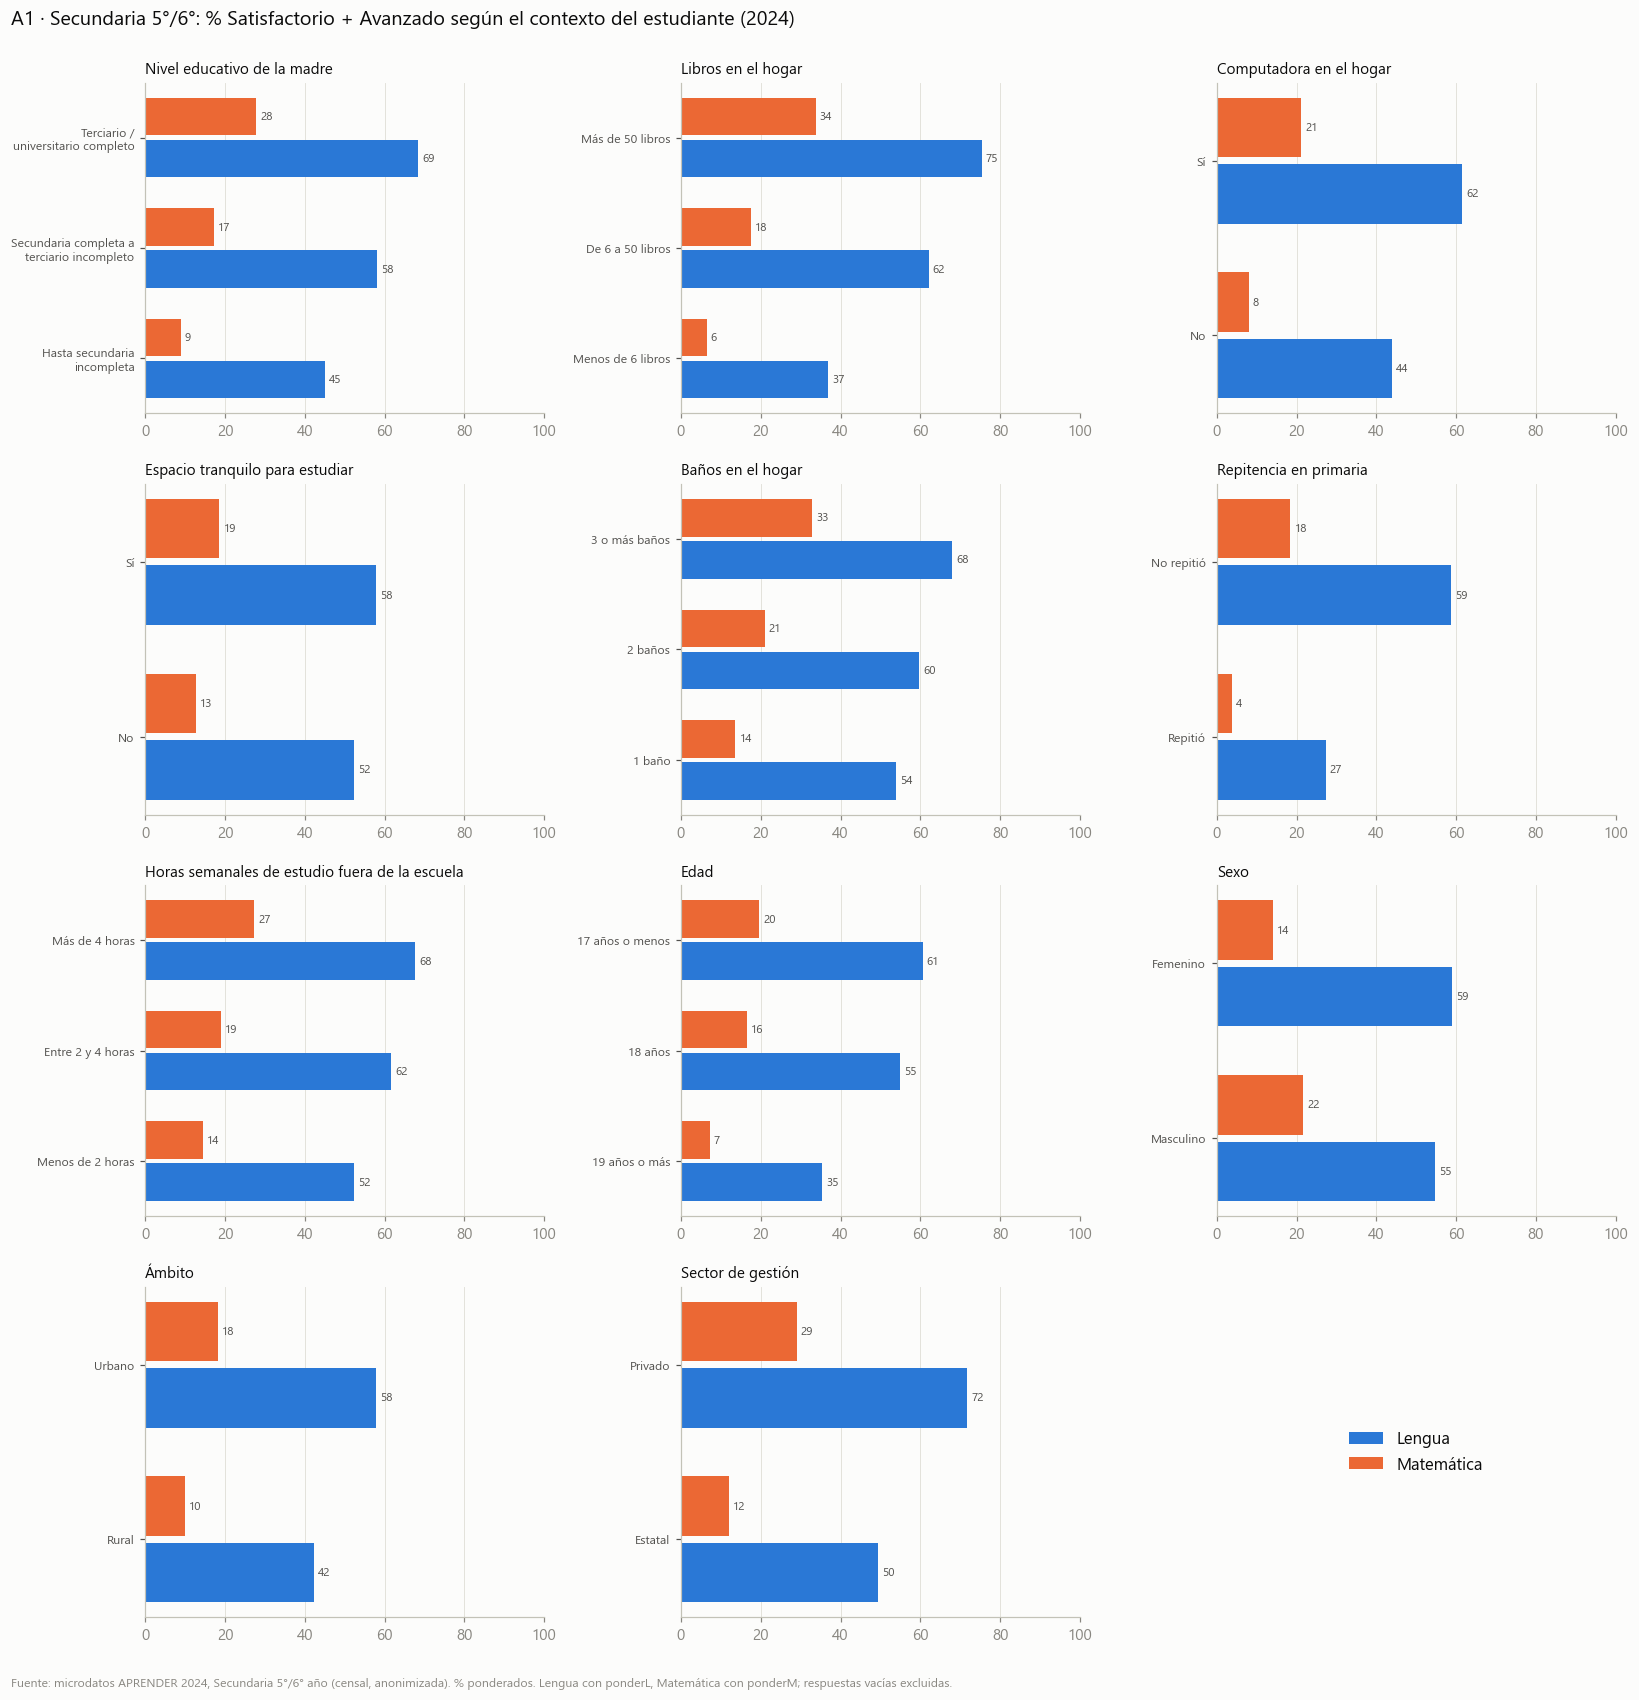

% Satisf+Avanz  \
variable                                       categoria                                  area                         
Nivel educativo de la madre                    Hasta secundaria incompleta                Lengua                45.0   
                                               Secundaria completa a terciario incompleto Lengua                58.0   
                                               Terciario / universitario completo         Lengua                68.5   
                                               Hasta secundaria incompleta                Matemática             8.9   
                                               Secundaria completa a terciario incompleto Matemática            17.1   
                                               Terciario / universitario completo         Matemática            27.8   
Libros en el hogar                             Menos de 6 libros                          Lengua                36.9   
                                               De 6 a 50 libros                           Lengua                62.1   
                                               Más de 50 libros                           Lengua                75.4   
                                               Menos de 6 libros                          Matemática             6.5   
                                               De 6 a 50 libros                           Matemática            17.6   
                                               Más de 50 libros                           Matemática            33.8   
Computadora en el hogar                        No                                         Lengua                43.9   
                                               Sí                                         Lengua                61.6   
                                               No                                         Matemática             8.0   
                                               Sí                                         Matemática            21.1   
Espacio tranquilo para estudiar                No                                         Lengua                52.4   
                                               Sí                                         Lengua                57.8   
                                               No                                         Matemática            12.7   
                                               Sí                                         Matemática            18.6   
Baños en el hogar                              1 baño                                     Lengua                53.8   
                                               2 baños                                    Lengua                59.8   
                                               3 o más baños                              Lengua                68.0   
                                               1 baño                                     Matemática            13.6   
                                               2 baños                                    Matemática            21.0   
                                               3 o más baños                              Matemática            32.8   
Repitencia en primaria                         Repitió                                    Lengua                27.3   
                                               No repitió                                 Lengua                58.6   
                                               Repitió                                    Matemática             3.9   
                                               No repitió                                 Matemática            18.5   
Horas semanales de estudio fuera de la escuela Menos de 2 horas                           Lengua                52.3   
                                               Entre 2 y 4 horas                          Lengua                61.8   
                      

,variable,area,menos_favorable,mas_favorable,brecha % Satisf+Avanz (pp),brecha puntaje
0,Nivel educativo de la madre,Lengua,Hasta secundaria incompleta,Terciario / universitario completo,23.5,63.8
1,Nivel educativo de la madre,Matemática,Hasta secundaria incompleta,Terciario / universitario completo,18.9,43.8
2,Libros en el hogar,Lengua,Menos de 6 libros,Más de 50 libros,38.5,104.4
3,Libros en el hogar,Matemática,Menos de 6 libros,Más de 50 libros,27.3,64.8
4,Computadora en el hogar,Lengua,No,Sí,17.6,46.3
5,Computadora en el hogar,Matemática,No,Sí,13.1,31.4
6,Espacio tranquilo para estudiar,Lengua,No,Sí,5.3,16.6
7,Espacio tranquilo para estudiar,Matemática,No,Sí,5.9,13.1
8,Baños en el hogar,Lengua,1 baño,3 o más baños,14.2,42.3
9,Baños en el hogar,Matemática,1 baño,3 o más baños,19.2,39.8


In [3]:
VARS_S = [
 ('Nivel_Ed_MadreX', 'Nivel educativo de la madre', ['Hasta secundaria incompleta', 'Hasta terciario  / universitario incompleto', 'Universitario - Terciario - Posgrado completo']),
 ('ap19X', 'Libros en el hogar', ['Menos de 6 libros', 'De 6 a 50 libros', 'Mas de 50 libros']),
 ('ap16g', 'Computadora en el hogar', ['No', 'Sí']),
 ('ap15', 'Espacio tranquilo para estudiar', ['No', 'Sí']),
 ('ap17', 'Baños en el hogar', ['1', '2', '3 o más']),
 ('ap25aX', 'Repitencia en primaria', ['Repeti en primaria', 'No repeti en primaria']),
 ('ap31X', 'Horas semanales de estudio fuera de la escuela', ['Menos de 2 horas', 'Entre 2 y 4 horas', 'Mas de 4 horas']),
 ('Edad', 'Edad', ['19 años o más', '18 años', '17 años o menos']),
 ('Sexo', 'Sexo', ['Masculino', 'Femenino']),
 ('ambito', 'Ámbito', ['Rural', 'Urbano']),
 ('sector', 'Sector de gestión', ['Estatal', 'Privado']),
]
ETQ = {'Hasta terciario  / universitario incompleto': 'Secundaria completa a terciario incompleto',
       'Universitario - Terciario - Posgrado completo': 'Terciario / universitario completo',
       'Mas de 50 libros': 'Más de 50 libros', 'Repeti en primaria': 'Repitió', 'No repeti en primaria': 'No repitió',
       'Mas de 4 horas': 'Más de 4 horas', '1': '1 baño', '2': '2 baños', '3 o más': '3 o más baños'}
ALTOS_S, BAJOS_S = ['Satisfactorio', 'Avanzado'], ['Por debajo del nivel básico']
for var, _, orden in VARS_S:
    faltan = set(orden) - set(SEC[var].dropna().unique())
    assert not faltan, f'{var}: categorías inexistentes {faltan}'

tablas_s = []
for var, nombre, orden in VARS_S:
    for area, (d, pt, p) in AREAS_S.items():
        t = resumen(SEC, d, pt, p, var, ALTOS_S, BAJOS_S, orden)
        tablas_s.append(t.rename(index=lambda i: ETQ.get(i, i)).assign(variable=nombre, area=area).reset_index(names='categoria'))
A1 = pd.concat(tablas_s, ignore_index=True)[['variable', 'categoria', 'area', '% altos', '% bajos', 'puntaje medio', '% de estudiantes', 'n']]
A1 = A1.rename(columns={'% altos': '% Satisf+Avanz', '% bajos': '% Debajo del básico'})

fig, axs = plt.subplots(4, 3, figsize=(15, 15))
for ax, (var, nombre, orden) in zip(axs.flat, VARS_S):
    t = A1[A1.variable == nombre]
    cats = [ETQ.get(o, o) for o in orden]
    y = np.arange(len(cats)); h = 0.38
    for k, (area, col) in enumerate([('Lengua', AZUL), ('Matemática', NARANJA)]):
        v = t[t.area == area].set_index('categoria').reindex(cats)['% Satisf+Avanz']
        ax.barh(y + (k - 0.5) * h, v, height=h - 0.04, color=col, label=area)
        for yi, vi in zip(y + (k - 0.5) * h, v):
            ax.text(vi + 1, yi, f'{vi:.0f}', va='center', fontsize=7.5, color=TINTA_2)
    ax.set_yticks(y); ax.set_yticklabels([textwrap.fill(c, 24) for c in cats], fontsize=8)
    ax.set_xlim(0, 100); ax.grid(axis='y', visible=False)
    ax.set_title(nombre, loc='left', fontsize=10)
axs.flat[-1].legend(*axs.flat[0].get_legend_handles_labels(), frameon=False, fontsize=11, loc='center')
axs.flat[-1].axis("off")
fig.suptitle('A1 · Secundaria 5°/6°: % Satisfactorio + Avanzado según el contexto del estudiante (2024)', x=0.01, ha='left', fontsize=13, y=1.0)
fig.tight_layout(h_pad=1.5)
nota(fig, FUENTE_S + ' Lengua con ponderL, Matemática con ponderM; respuestas vacías excluidas.')
guardar(fig, 'A1_secundaria_contexto'); plt.show()

def brechas(tab, altos='% Satisf+Avanz'):
    filas = []
    for (var, area), t in tab.groupby(['variable', 'area'], sort=False):
        filas.append(dict(variable=var, area=area, menos_favorable=t.categoria.iloc[0], mas_favorable=t.categoria.iloc[-1],
                          **{f'brecha {altos} (pp)': t[altos].iloc[-1] - t[altos].iloc[0],
                             'brecha puntaje': t['puntaje medio'].iloc[-1] - t['puntaje medio'].iloc[0]}))
    return pd.DataFrame(filas)
A1_BRECHAS = brechas(A1)
display(A1.set_index(['variable', 'categoria', 'area']).round(1))
display(A1_BRECHAS.round(1))

### A2 · Recursos del hogar acumulados
Conteo simple (0 a 5) de: madre con terciario/universitario completo, más de 50 libros, computadora, espacio tranquilo
para estudiar y 2 o más baños. No es un índice socioeconómico oficial: resume cuántas de estas ventajas tiene el hogar.
Solo estudiantes con las cinco preguntas respondidas.

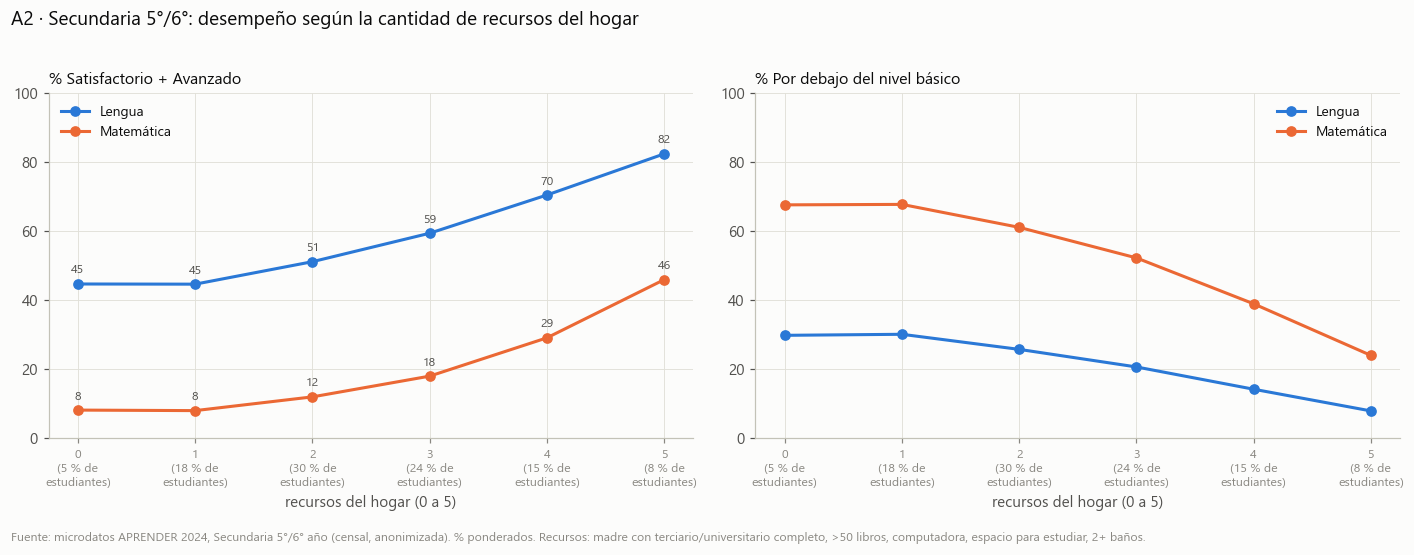

% Satisf+Avanz  % Debajo del básico  puntaje medio  \
area       recursos                                                       
Lengua     0                   44.7                 29.8          476.2   
           1                   44.6                 30.1          477.0   
           2                   51.1                 25.7          493.2   
           3                   59.4                 20.6          514.2   
           4                   70.5                 14.2          546.3   
           5                   82.4                  7.9          588.3   
Matemática 0                    8.1                 67.6          443.2   
           1                    7.9                 67.7          443.5   
           2                   11.9                 61.1          453.8   
           3                   17.9                 52.2          468.6   
           4                   29.1                 38.9          492.6   
           5                   45.9                 24.0          524.8   

                     % de estudiantes       n  
area       recursos                            
Lengua     0                      4.8   16511  
           1                     18.0   63855  
           2                     30.3  110444  
           3                     24.3   92012  
           4                     14.9   59408  
           5                      7.7   31744  
Matemática 0                      4.7   16321  
           1                     18.0   62990  
           2                     30.3  109237  
           3                     24.3   91240  
           4                     14.9   59043  
           5                      7.7   31699

In [4]:
comp = pd.DataFrame({
    'madre_terciaria': SEC.Nivel_Ed_MadreX.eq('Universitario - Terciario - Posgrado completo'),
    'mas_50_libros': SEC.ap19X.eq('Mas de 50 libros'), 'computadora': SEC.ap16g.eq('Sí'),
    'espacio': SEC.ap15.eq('Sí'), 'banos_2_mas': SEC.ap17.isin(['2', '3 o más'])})
completo = SEC[['Nivel_Ed_MadreX', 'ap19X', 'ap16g', 'ap15', 'ap17']].notna().all(axis=1)
SEC['recursos_hogar'] = comp.sum(axis=1).where(completo).astype('Int64')
A2 = pd.concat({area: resumen(SEC, d, pt, p, 'recursos_hogar', ALTOS_S, BAJOS_S, list(range(6)))
                for area, (d, pt, p) in AREAS_S.items()}, names=['area', 'recursos'])
A2 = A2.rename(columns={'% altos': '% Satisf+Avanz', '% bajos': '% Debajo del básico'})

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
for area, col in [('Lengua', AZUL), ('Matemática', NARANJA)]:
    t = A2.loc[area]
    axs[0].plot(t.index, t['% Satisf+Avanz'], color=col, lw=2, marker='o', label=area)
    for xi, yi in t['% Satisf+Avanz'].items():
        axs[0].annotate(f'{yi:.0f}', (xi, yi), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, color=TINTA_2)
    axs[1].plot(t.index, t['% Debajo del básico'], color=col, lw=2, marker='o', label=area)
t = A2.loc['Lengua']
axs[0].set_title('% Satisfactorio + Avanzado', loc='left', fontsize=10.5); axs[0].set_ylim(0, 100)
axs[1].set_title('% Por debajo del nivel básico', loc='left', fontsize=10.5); axs[1].set_ylim(0, 100)
for ax in axs:
    ax.set_xticks(t.index); ax.set_xticklabels([f'{i}\n({s:.0f} % de\nestudiantes)' for i, s in t['% de estudiantes'].items()], fontsize=8)
    ax.set_xlabel('recursos del hogar (0 a 5)'); ax.legend(frameon=False, fontsize=9)
fig.suptitle('A2 · Secundaria 5°/6°: desempeño según la cantidad de recursos del hogar', x=0.01, ha='left', fontsize=12.5, y=1.02)
fig.tight_layout(); nota(fig, FUENTE_S + ' Recursos: madre con terciario/universitario completo, >50 libros, computadora, espacio para estudiar, 2+ baños.')
guardar(fig, 'A2_secundaria_recursos_hogar'); plt.show()
display(A2.round(1))

### A3 · Estatal y privado a igual contexto
Si la ventaja del sector privado se debiera solo a que sus estudiantes vienen de hogares con más recursos, la brecha
desaparecería al comparar estudiantes con el mismo contexto. Se compara dentro de cada nivel educativo de la madre y de
cada grupo de recursos del hogar.

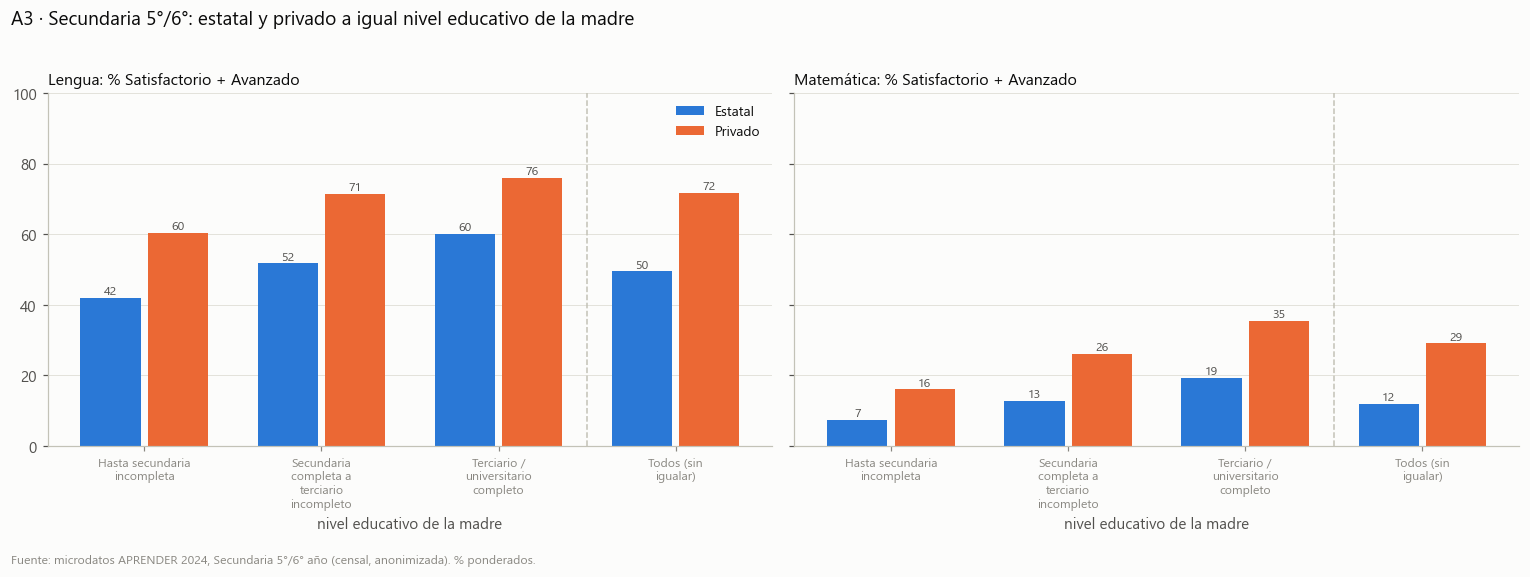

sector                                                                       Estatal  \
area       igualando_por         estrato                                               
Lengua     educación de la madre Hasta secundaria incompleta                    42.0   
                                 Secundaria completa a terciario incompleto     51.7   
                                 Terciario / universitario completo             60.2   
                                 Todos (sin igualar)                            49.5   
           recursos del hogar    0–1 recursos                                   42.4   
                                 2–3 recursos                                   49.4   
                                 4–5 recursos                                   66.7   
                                 Todos (sin igualar)                            49.5   
Matemática educación de la madre Hasta secundaria incompleta                     7.4   
                                 Secundaria completa a terciario incompleto     12.8   
                                 Terciario / universitario completo             19.2   
                                 Todos (sin igualar)                            12.0   
           recursos del hogar    0–1 recursos                                    7.1   
                                 2–3 recursos                                   11.5   
                                 4–5 recursos                                   25.8   
                                 Todos (sin igualar)                            12.0   

sector                                                                       Privado  \
area       igualando_por         estrato                                               
Lengua     educación de la madre Hasta secundaria incompleta                    60.4   
                                 Secundaria completa a terciario incompleto     71.4   
                                 Terciario / universitario completo             75.9   
                                 Todos (sin igualar)                            71.8   
           recursos del hogar    0–1 recursos                                   58.1   
                                 2–3 recursos                                   68.0   
                                 4–5 recursos                                   79.1   
                                 Todos (sin igualar)                            71.8   
Matemática educación de la madre Hasta secundaria incompleta                    16.1   
                                 Secundaria completa a terciario incompleto     26.2   
                                 Terciario / universitario completo             35.4   
                                 Todos (sin igualar)                            29.0   
           recursos del hogar    0–1 recursos                                   13.6   
                                 2–3 recursos                                   22.2   
                                 4–5 recursos                                   40.1   
                                 Todos (sin igualar)                            29.0   

sector                                                                       brecha privado − estatal (pp)  
area       igualando_por         estrato                                                                    
Lengua     educación de la madre Hasta secundaria incompleta                                          18.4  
                                 Secundaria completa a terciario incompleto                           19.7  
                                 Terciario / universitario completo                                   15.7  
                                 Todos (sin igualar)                                                  22.3  
           recursos del hogar    0–1 recursos                                                         15.6  
                                 2–3 recursos                      

In [5]:
def a_igual(df, estrato, orden, desemp, puntaje, peso, altos, bajos):
    filas = []
    for e in orden:
        x = df[df[estrato] == e]
        t = resumen(x, desemp, puntaje, peso, 'sector', altos, bajos, ['Estatal', 'Privado'])
        filas.append(t.assign(estrato=ETQ.get(e, e)).reset_index(names='sector'))
    t = resumen(df, desemp, puntaje, peso, 'sector', altos, bajos, ['Estatal', 'Privado'])
    filas.append(t.assign(estrato='Todos (sin igualar)').reset_index(names='sector'))
    return pd.concat(filas, ignore_index=True)

orden_madre = VARS_S[0][2]
SEC['recursos_grupo'] = pd.cut(SEC.recursos_hogar.astype('float'), [-1, 1, 3, 5], labels=['0–1 recursos', '2–3 recursos', '4–5 recursos']).astype('string')
A3 = []
for area, (d, pt, p) in AREAS_S.items():
    for nombre_e, var_e, orden_e in [('educación de la madre', 'Nivel_Ed_MadreX', orden_madre),
                                     ('recursos del hogar', 'recursos_grupo', ['0–1 recursos', '2–3 recursos', '4–5 recursos'])]:
        A3.append(a_igual(SEC, var_e, orden_e, d, pt, p, ALTOS_S, BAJOS_S).assign(area=area, igualando_por=nombre_e))
A3 = pd.concat(A3, ignore_index=True).rename(columns={'% altos': '% Satisf+Avanz', '% bajos': '% Debajo del básico'})
A3_BRECHA = (A3.pivot_table(index=['area', 'igualando_por', 'estrato'], columns='sector', values='% Satisf+Avanz')
             .assign(**{'brecha privado − estatal (pp)': lambda t: t.Privado - t.Estatal}))
orden_filas = [(a, ig, ETQ.get(e, e)) for a in AREAS_S
               for ig, estratos in [('educación de la madre', orden_madre), ('recursos del hogar', ['0–1 recursos', '2–3 recursos', '4–5 recursos'])]
               for e in estratos + ['Todos (sin igualar)']]
A3_BRECHA = A3_BRECHA.reindex(orden_filas)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, area in zip(axs, AREAS_S):
    t = A3[(A3.area == area) & (A3.igualando_por == 'educación de la madre')]
    cats = list(dict.fromkeys(t.estrato))
    x = np.arange(len(cats)); w = 0.38
    for k, (sec, col) in enumerate([('Estatal', AZUL), ('Privado', NARANJA)]):
        v = t[t.sector == sec].set_index('estrato').reindex(cats)['% Satisf+Avanz']
        ax.bar(x + (k - 0.5) * w, v, width=w - 0.04, color=col, label=sec)
        for xi, vi in zip(x + (k - 0.5) * w, v):
            ax.text(xi, vi + 1, f'{vi:.0f}', ha='center', fontsize=8, color=TINTA_2)
    ax.set_xticks(x); ax.set_xticklabels([textwrap.fill(c, 18) for c in cats], fontsize=8)
    ax.set_title(f'{area}: % Satisfactorio + Avanzado', loc='left', fontsize=10.5); ax.grid(axis='x', visible=False)
    ax.axvline(len(cats) - 1.5, color=EJE, lw=1, ls='--')
axs[0].set_xlabel('nivel educativo de la madre'); axs[1].set_xlabel('nivel educativo de la madre')
axs[0].legend(frameon=False, fontsize=9); axs[0].set_ylim(0, 100)
fig.suptitle('A3 · Secundaria 5°/6°: estatal y privado a igual nivel educativo de la madre', x=0.01, ha='left', fontsize=12.5, y=1.02)
fig.tight_layout(); nota(fig, FUENTE_S)
guardar(fig, 'A3_secundaria_sector_igual_contexto'); plt.show()
display(A3_BRECHA.round(1))

### A4 · Provincias a igual composición de los hogares
**Estandarización directa:** para cada provincia se calcula el % Satisfactorio + Avanzado dentro de cada combinación de
educación de la madre × libros en el hogar (9 grupos) y se promedia con la **distribución nacional** de esos grupos. El
resultado responde: *¿cuánto rendiría la provincia si sus estudiantes vinieran de hogares con la misma composición que el
país?* La diferencia con el valor observado indica cuánto de la posición de la provincia se explica por la composición.

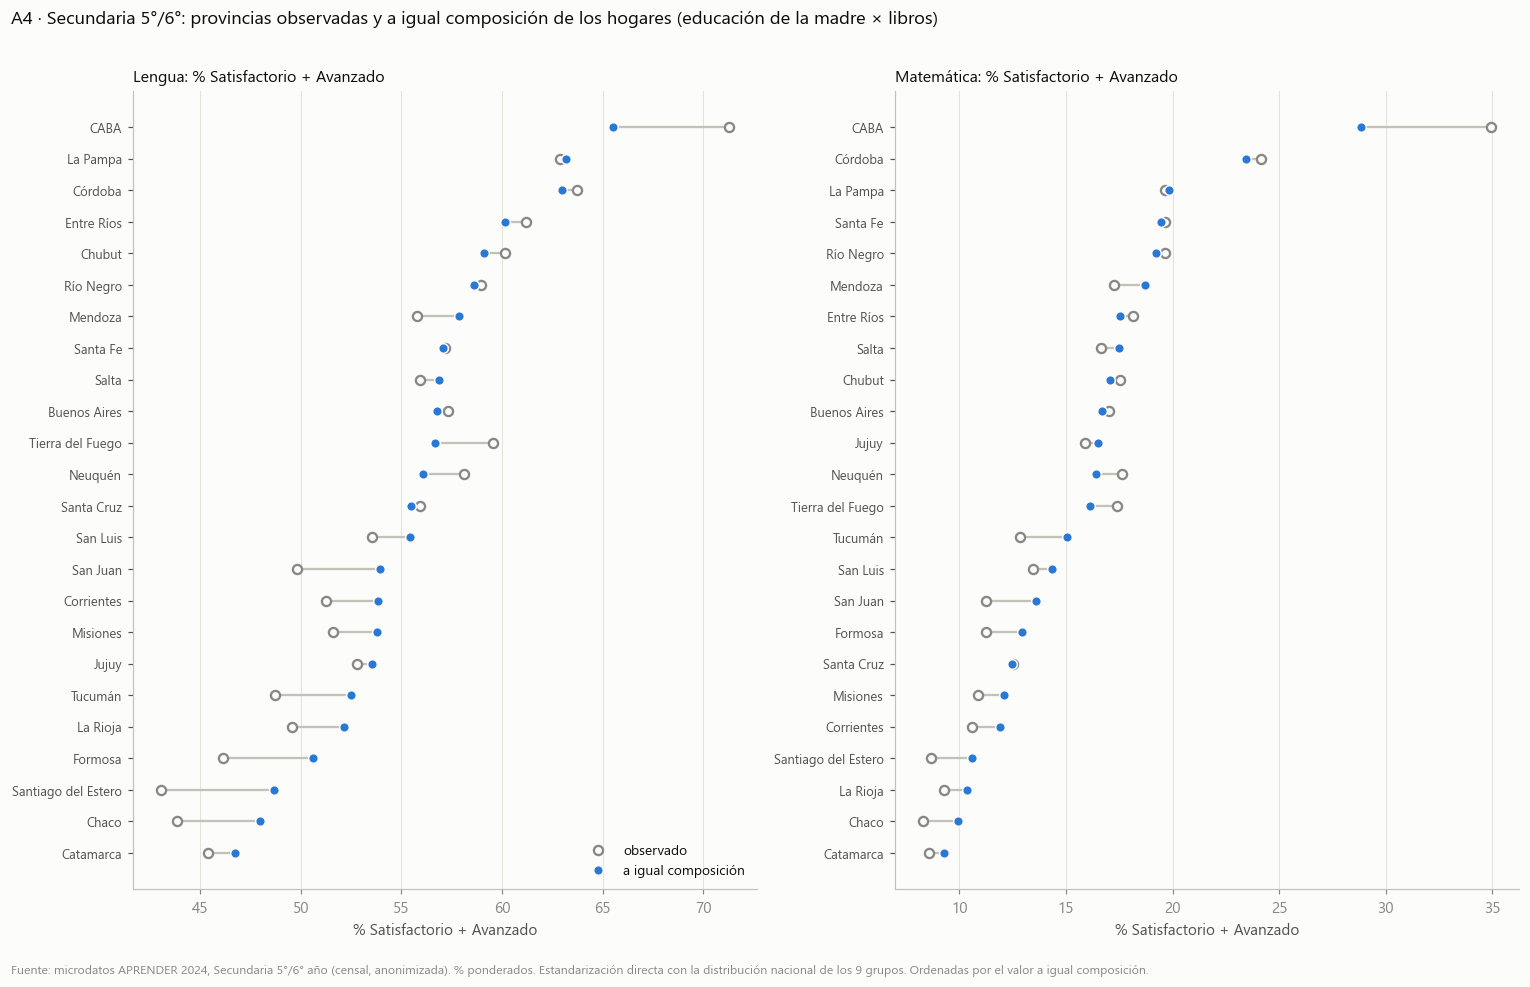

rango_pp                     desvio_pp  \
medida                  observado a igual composición observado   
serie                                                             
Secundaria · Lengua          28.2                18.8       6.9   
Secundaria · Matemática      26.7                19.6       6.0   

                                            reducción del rango  
medida                  a igual composición                   %  
serie                                                            
Secundaria · Lengua                     4.7                33.4  
Secundaria · Matemática                 4.6                26.6


Lengua


,observado,a igual composición,diferencia (pp),grupos sin estudiantes,celda mínima (n),n,rank observado,rank a igual composición
provincia,,,,,,,,
CABA,71.3,65.5,-5.7,0,654,22417,1,1
La Pampa,62.9,63.2,0.3,0,102,3362,3,2
Córdoba,63.7,63.0,-0.8,0,1059,37100,2,3
Entre Ríos,61.2,60.1,-1.1,0,288,9844,4,4
Chubut,60.2,59.1,-1.0,0,170,4905,5,5
Río Negro,59.0,58.6,-0.4,0,213,6292,7,6
Mendoza,55.8,57.9,2.1,0,364,18027,13,7
Santa Fe,57.2,57.1,-0.1,0,684,27427,10,8
Salta,55.9,56.9,1.0,0,520,14875,12,9



Matemática


,observado,a igual composición,diferencia (pp),grupos sin estudiantes,celda mínima (n),n,rank observado,rank a igual composición
provincia,,,,,,,,
CABA,34.9,28.9,-6.1,0,650,22266,1,1
Córdoba,24.1,23.4,-0.7,0,1057,37051,2,2
La Pampa,19.7,19.8,0.2,0,102,3325,4,3
Santa Fe,19.7,19.4,-0.2,0,680,27227,3,4
Río Negro,19.6,19.2,-0.4,0,209,6090,5,5
Mendoza,17.3,18.7,1.4,0,356,17968,10,6
Entre Ríos,18.2,17.5,-0.6,0,286,9789,6,7
Salta,16.7,17.5,0.8,0,520,14901,12,8
Chubut,17.5,17.1,-0.5,0,160,4838,8,9


In [6]:
SEC['estrato_hogar'] = (SEC.Nivel_Ed_MadreX + ' | ' + SEC.ap19X).astype('string')

def estandarizar(df, estrato, desemp, peso, altos, por='provincia'):
    x = df[df[desemp].notna() & df[peso].notna() & df[estrato].notna()]
    x = x.assign(_alto=x[desemp].isin(altos).astype(float) * x[peso])
    celdas = x.groupby([por, estrato], observed=True).agg(alto=('_alto', 'sum'), w=(peso, 'sum'), n=(peso, 'size'))
    celdas['pct'] = 100 * celdas.alto / celdas.w
    nacional = x.groupby(estrato, observed=True)[peso].sum(); nacional = nacional / nacional.sum()
    pct = celdas.pct.unstack(estrato)
    faltan = pct.isna()
    est = (pct.fillna(0) * nacional).sum(axis=1) / (nacional * (~faltan)).sum(axis=1)   # reescala si falta un grupo
    obs = x.groupby(por, observed=True)._alto.sum() / x.groupby(por, observed=True)[peso].sum() * 100
    out = pd.DataFrame({'observado': obs, 'a igual composición': est})
    out['diferencia (pp)'] = out['a igual composición'] - out['observado']
    out['grupos sin estudiantes'] = faltan.sum(axis=1)
    out['celda mínima (n)'] = celdas.n.unstack(estrato).min(axis=1)
    out['n'] = x.groupby(por, observed=True).size()
    out['rank observado'] = out.observado.rank(ascending=False).astype(int)
    out['rank a igual composición'] = out['a igual composición'].rank(ascending=False).astype(int)
    return out.sort_values('a igual composición', ascending=False)

A4 = {area: estandarizar(SEC, 'estrato_hogar', d, p, ALTOS_S) for area, (d, _, p) in AREAS_S.items()}
assert all(len(t) == 24 for t in A4.values())

def dumbbell(ax, t, titulo, xlabel):
    t = t.iloc[::-1]
    y = np.arange(len(t))
    for yi, (o, e) in zip(y, t[['observado', 'a igual composición']].values):
        ax.plot([o, e], [yi, yi], color=EJE, lw=1.5, zorder=1)
    ax.scatter(t.observado, y, s=36, facecolor=SUPERFICIE, edgecolor=TENUE, linewidth=1.5, zorder=2, label='observado')
    ax.scatter(t['a igual composición'], y, s=40, color=AZUL, edgecolor=SUPERFICIE, linewidth=1, zorder=3, label='a igual composición')
    poco_n = (t['celda mínima (n)'] < 50) | (t['grupos sin estudiantes'] > 0)
    ax.set_yticks(y); ax.set_yticklabels([f'{p} †' if b else p for p, b in zip(t.index, poco_n)], fontsize=8.5)
    ax.set_title(titulo, loc='left', fontsize=10.5); ax.set_xlabel(xlabel); ax.grid(axis='y', visible=False)

def dispersion_provincial(tablas):
    """Rango y desvío entre provincias, observado y a igual composición, y cuánto se reduce."""
    filas = []
    for nombre, t in tablas.items():
        for col in ['observado', 'a igual composición']:
            filas.append(dict(serie=nombre, medida=col, rango_pp=t[col].max() - t[col].min(), desvio_pp=t[col].std()))
    d = pd.DataFrame(filas).pivot_table(index='serie', columns='medida', values=['rango_pp', 'desvio_pp'], sort=False)
    d[('reducción del rango', '%')] = 100 * (1 - d[('rango_pp', 'a igual composición')] / d[('rango_pp', 'observado')])
    return d

fig, axs = plt.subplots(1, 2, figsize=(14, 8.5))
for ax, area in zip(axs, AREAS_S):
    dumbbell(ax, A4[area], f'{area}: % Satisfactorio + Avanzado', '% Satisfactorio + Avanzado')
axs[0].legend(frameon=False, fontsize=9, loc='lower right')
fig.suptitle('A4 · Secundaria 5°/6°: provincias observadas y a igual composición de los hogares (educación de la madre × libros)',
             x=0.01, ha='left', fontsize=12, y=1.01)
fig.tight_layout(); nota(fig, FUENTE_S + ' Estandarización directa con la distribución nacional de los 9 grupos. Ordenadas por el valor a igual composición.')
guardar(fig, 'A4_secundaria_provincias_igual_composicion'); plt.show()
A4_DISP = dispersion_provincial({f'Secundaria · {a}': t for a, t in A4.items()})
display(A4_DISP.round(1))
for area in AREAS_S:
    print(f'\n{area}'); display(A4[area].round(1))

---
## B · Primaria 3° grado — lectura (muestral)
### B1 · Desempeño según cada variable de contexto
Se usan los **dos niveles más altos** (IV y V) y los **tres más bajos** (lector incipiente, I y II) de la escala de lectura
de 6 niveles, y el puntaje medio. *n* = estudiantes de la muestra en cada categoría.

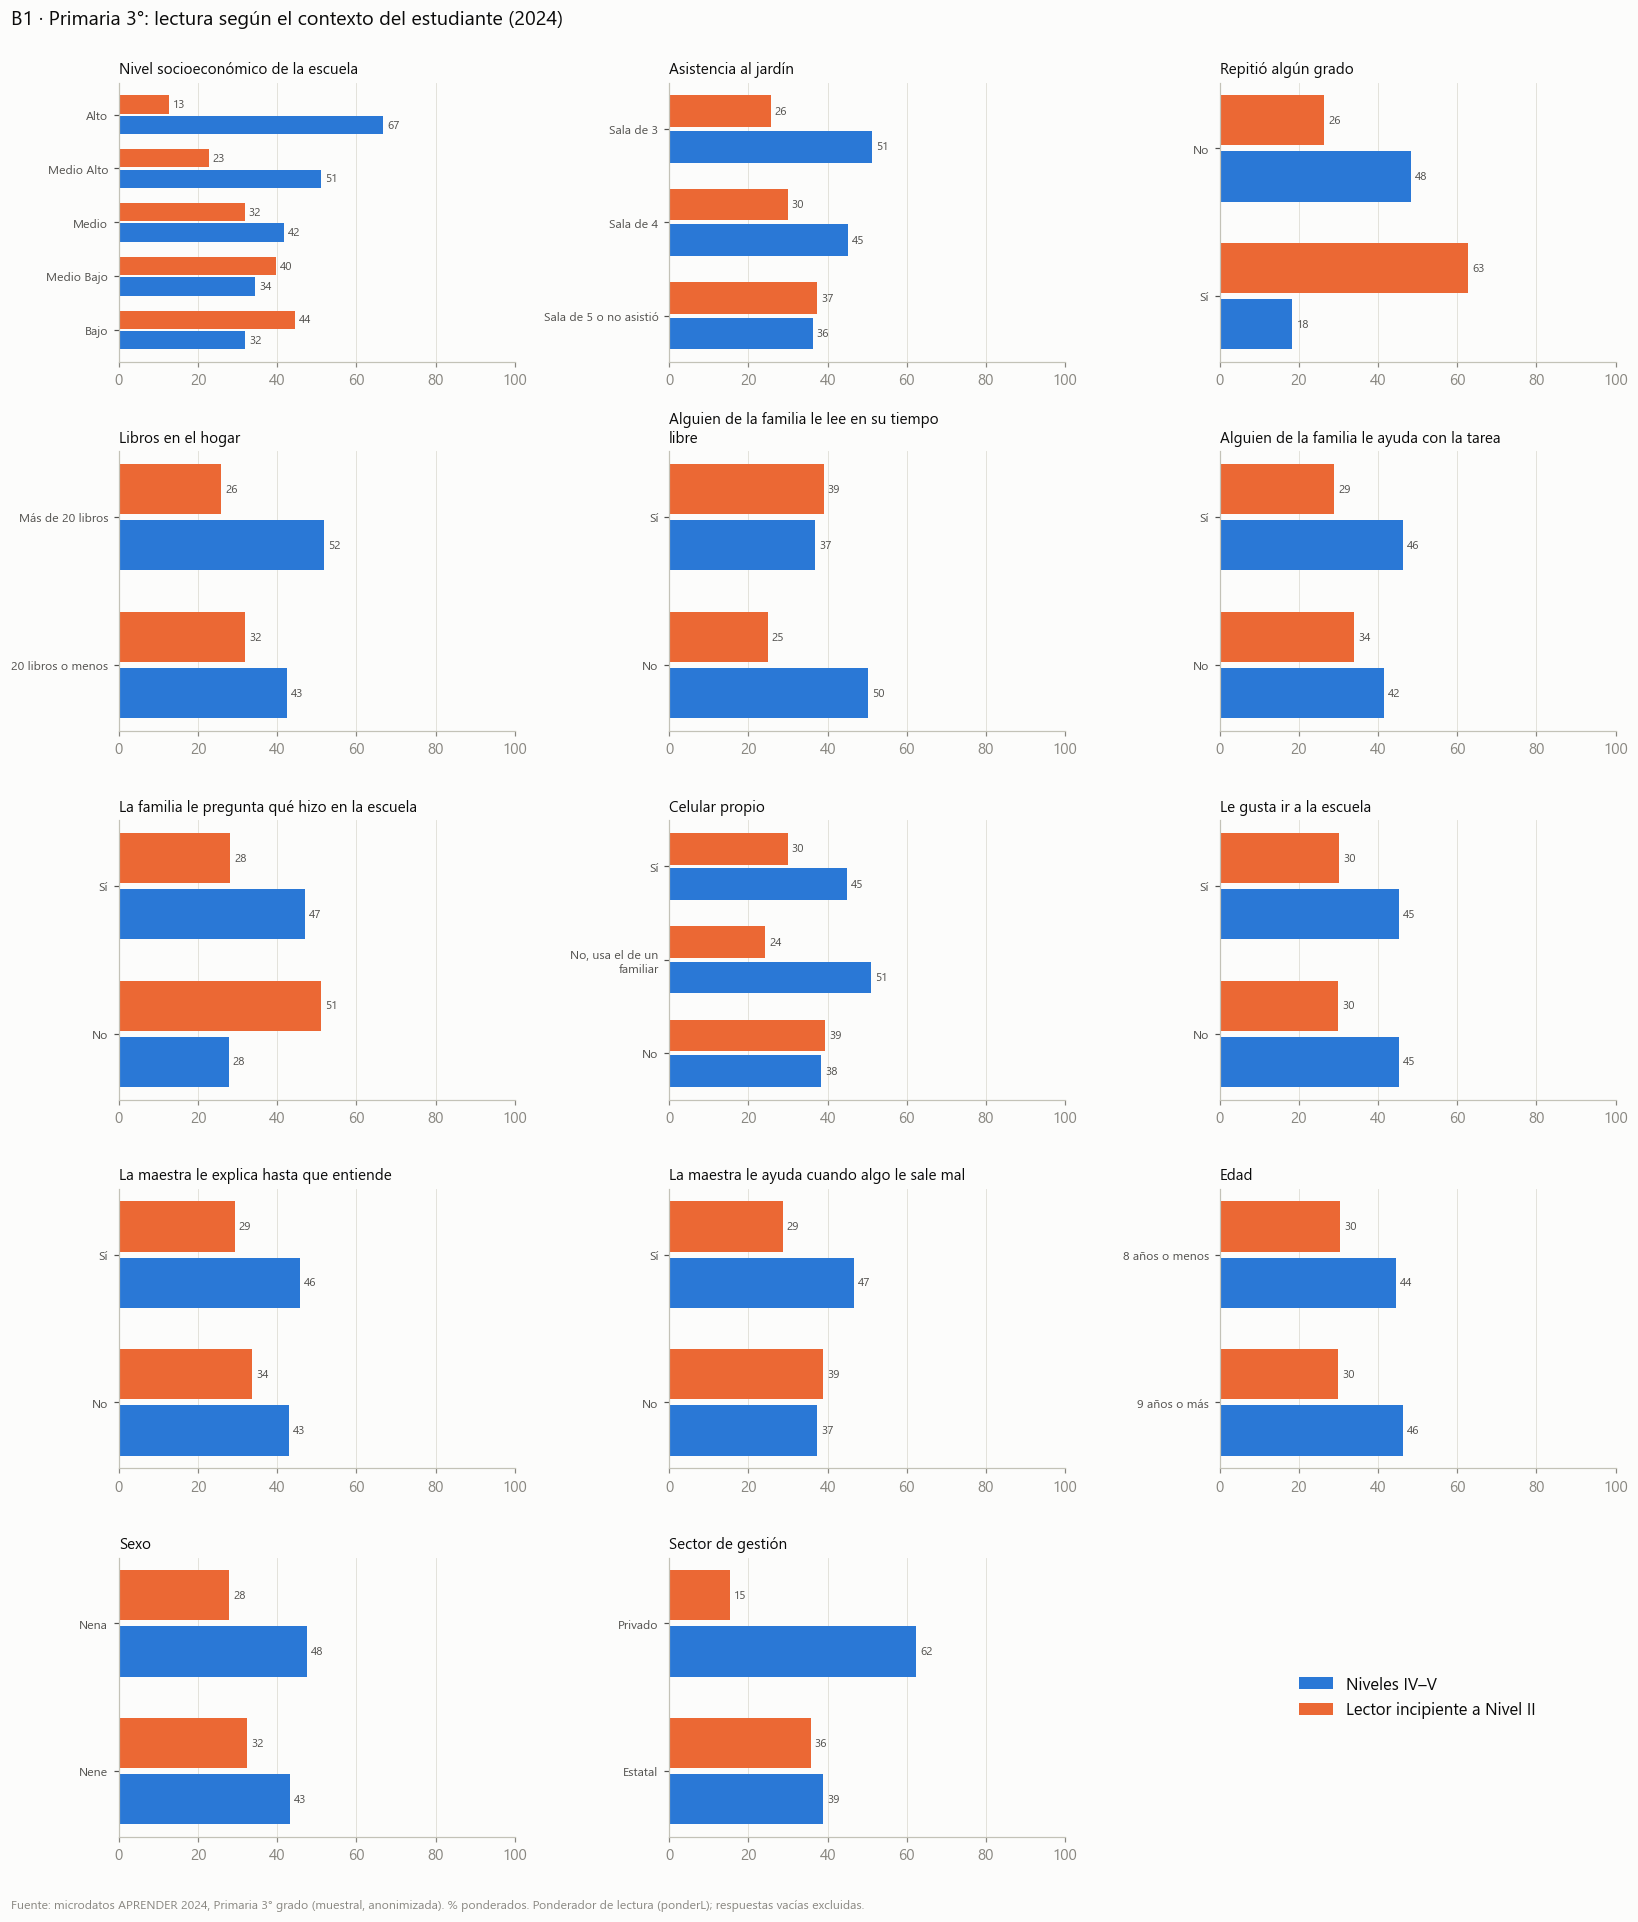

% Niveles IV–V  \
variable                                        categoria                                   
Nivel socioeconómico de la escuela              Bajo                                 32.0   
                                                Medio Bajo                           34.4   
                                                Medio                                41.6   
                                                Medio Alto                           51.0   
                                                Alto                                 66.7   
Asistencia al jardín                            Sala de 5 o no asistió               36.2   
                                                Sala de 4                            45.2   
                                                Sala de 3                            51.1   
Repitió algún grado                             Sí                                   18.4   
                                                No                                   48.4   
Libros en el hogar                              20 libros o menos                    42.6   
                                                Más de 20 libros                     51.8   
Alguien de la familia le lee en su tiempo libre No                                   50.3   
                                                Sí                                   36.8   
Alguien de la familia le ayuda con la tarea     No                                   41.6   
                                                Sí                                   46.3   
La familia le pregunta qué hizo en la escuela   No                                   27.7   
                                                Sí                                   46.9   
Celular propio                                  No                                   38.4   
                                                No, usa el de un familiar            50.9   
                                                Sí                                   45.0   
Le gusta ir a la escuela                        No                                   45.4   
                                                Sí                                   45.3   
La maestra le explica hasta que entiende        No                                   42.9   
                                                Sí                                   45.8   
La maestra le ayuda cuando algo le sale mal     No                                   37.3   
                                                Sí                                   46.5   
Edad                                            9 años o más                         46.2   
                                                8 años o menos                       44.4   
Sexo                                            Nene                                 43.1   
                                                Nena                                 47.5   
Sector de gestión                               Estatal                              39.0   
                                                Privado                              62.4   

                                                                           % Lector incipiente a Nivel II  \
variable                                        categoria                                                   
Nivel socioeconómico de la escuela              Bajo                                                 44.4   
                                                Medio Bajo                                           39.8   
                                                Medio                                                31.8   
                                                Medio Alto                                           22.7   
                                                Alto                                                 12.6   
Asistencia al jardín                            Sala de 

,variable,area,menos_favorable,mas_favorable,brecha % Niveles IV–V (pp),brecha puntaje
0,Nivel socioeconómico de la escuela,Lectura,Bajo,Alto,34.7,98.2
1,Asistencia al jardín,Lectura,Sala de 5 o no asistió,Sala de 3,14.9,38.4
2,Repitió algún grado,Lectura,Sí,No,30.0,99.5
3,Libros en el hogar,Lectura,20 libros o menos,Más de 20 libros,9.3,24.8
4,Alguien de la familia le lee en su tiempo libre,Lectura,No,Sí,-13.4,-39.5
5,Alguien de la familia le ayuda con la tarea,Lectura,No,Sí,4.8,12.8
6,La familia le pregunta qué hizo en la escuela,Lectura,No,Sí,19.2,60.6
7,Celular propio,Lectura,No,Sí,6.5,24.3
8,Le gusta ir a la escuela,Lectura,No,Sí,-0.1,1.0
9,La maestra le explica hasta que entiende,Lectura,No,Sí,2.9,9.7


In [7]:
ALTOS_P, BAJOS_P = ['Nivel IV', 'Nivel V'], ['Lector incipiente', 'Nivel I', 'Nivel II']
ORDEN_NSE = ['Bajo', 'Medio Bajo', 'Medio', 'Medio Alto', 'Alto']
VARS_P = [
 ('NSE_escuela', 'Nivel socioeconómico de la escuela', ORDEN_NSE),
 ('Jardin', 'Asistencia al jardín', ['Sala de cinco / no asistió', 'Sala de cuatro', 'Sala de tres']),
 ('Repitencia', 'Repitió algún grado', ['Si', 'No']),
 ('Libros', 'Libros en el hogar', ['Veinte libros o menos', 'Más de veinte libros']),
 ('ap17', 'Alguien de la familia le lee en su tiempo libre', ['No', 'Sí']),
 ('ap12', 'Alguien de la familia le ayuda con la tarea', ['No', 'Sí']),
 ('ap11', 'La familia le pregunta qué hizo en la escuela', ['No', 'Sí']),
 ('ap08', 'Celular propio', ['No', 'No, pero uso el de mi mamá, papá o familiar', 'Sí']),
 ('ap13', 'Le gusta ir a la escuela', ['No, no me gusta', 'Sí, me gusta']),
 ('ap15a', 'La maestra le explica hasta que entiende', ['No', 'Sí']),
 ('ap15d', 'La maestra le ayuda cuando algo le sale mal', ['No', 'Sí']),
 ('Edad', 'Edad', ['9 años o más', '8 años o menos']),
 ('Sexo', 'Sexo', ['Nene', 'Nena']),
 ('sector', 'Sector de gestión', ['Estatal', 'Privado']),
]
ETQ.update({'Sala de cinco / no asistió': 'Sala de 5 o no asistió', 'Sala de cuatro': 'Sala de 4', 'Sala de tres': 'Sala de 3',
            'Si': 'Sí', 'Veinte libros o menos': '20 libros o menos', 'Más de veinte libros': 'Más de 20 libros',
            'No, pero uso el de mi mamá, papá o familiar': 'No, usa el de un familiar', 'No, no me gusta': 'No', 'Sí, me gusta': 'Sí'})
for var, _, orden in VARS_P:
    faltan = set(orden) - set(PRI[var].dropna().unique())
    assert not faltan, f'{var}: categorías inexistentes {faltan}'

B1 = pd.concat([resumen(PRI, 'ldesemp', 'lpuntaje', 'ponderL', var, ALTOS_P, BAJOS_P, orden)
                .rename(index=lambda i: ETQ.get(i, i)).assign(variable=nombre).reset_index(names='categoria')
                for var, nombre, orden in VARS_P], ignore_index=True)
B1 = B1[['variable', 'categoria', '% altos', '% bajos', 'puntaje medio', '% de estudiantes', 'n']].rename(
    columns={'% altos': '% Niveles IV–V', '% bajos': '% Lector incipiente a Nivel II'})

fig, axs = plt.subplots(5, 3, figsize=(15, 17))
for ax, (var, nombre, orden) in zip(axs.flat, VARS_P):
    t = B1[B1.variable == nombre].set_index('categoria').reindex([ETQ.get(o, o) for o in orden])
    y = np.arange(len(t)); h = 0.38
    ax.barh(y - h / 2, t['% Niveles IV–V'], height=h - 0.04, color=AZUL, label='Niveles IV–V')
    ax.barh(y + h / 2, t['% Lector incipiente a Nivel II'], height=h - 0.04, color=NARANJA, label='Lector incipiente a Nivel II')
    for yi, a, b_ in zip(y, t['% Niveles IV–V'], t['% Lector incipiente a Nivel II']):
        ax.text(a + 1, yi - h / 2, f'{a:.0f}', va='center', fontsize=7.5, color=TINTA_2)
        ax.text(b_ + 1, yi + h / 2, f'{b_:.0f}', va='center', fontsize=7.5, color=TINTA_2)
    ax.set_yticks(y); ax.set_yticklabels([textwrap.fill(c, 22) for c in t.index], fontsize=8)
    ax.set_xlim(0, 100); ax.grid(axis='y', visible=False); ax.set_title(textwrap.fill(nombre, 45), loc='left', fontsize=10)
axs.flat[-1].legend(*axs.flat[0].get_legend_handles_labels(), frameon=False, fontsize=11, loc='center')
axs.flat[-1].axis("off")
fig.suptitle('B1 · Primaria 3°: lectura según el contexto del estudiante (2024)', x=0.01, ha='left', fontsize=13, y=1.0)
fig.tight_layout(h_pad=1.5)
nota(fig, FUENTE_P + ' Ponderador de lectura (ponderL); respuestas vacías excluidas.')
guardar(fig, 'B1_primaria_contexto'); plt.show()
B1_BRECHAS = brechas(B1.assign(area='Lectura'), altos='% Niveles IV–V')
display(B1.set_index(['variable', 'categoria']).round(1)); display(B1_BRECHAS.round(1))

### B2 · A igual nivel socioeconómico de la escuela
El NSE de la escuela se asocia con casi todo lo demás (libros, jardín, lectura en casa). Para ver si esos factores siguen
asociados a mejor lectura **entre estudiantes de escuelas del mismo NSE**, se compara dentro de cada nivel. También el
sector: ¿el privado lee mejor que el estatal en escuelas del mismo NSE?

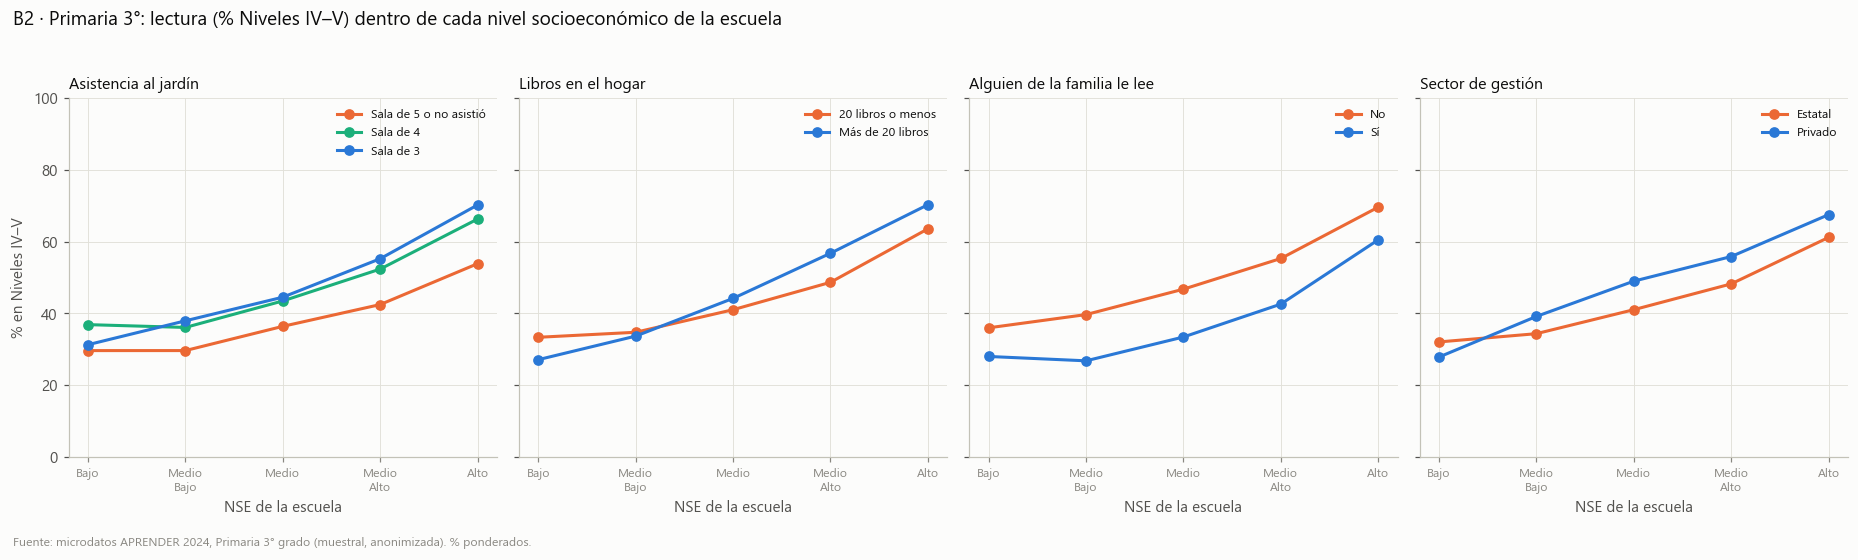

,NSE_escuela,Bajo,Medio Bajo,Medio,Medio Alto,Alto
variable,comparación,,,,,
Asistencia al jardín,Sala de 3 − Sala de 5 o no asistió,1.6,8.3,8.1,12.8,16.4
Libros en el hogar,Más de 20 libros − 20 libros o menos,-6.2,-1.1,3.2,8.1,6.7
Alguien de la familia le lee,Sí − No,-8.0,-12.9,-13.3,-12.7,-9.1
Repitió algún grado,No − Sí,17.1,23.1,27.5,36.8,41.4
Sector de gestión,Privado − Estatal,-4.2,4.8,8.0,7.6,6.3


In [8]:
B2 = []
for var, nombre, orden in [('Jardin', 'Asistencia al jardín', ['Sala de cinco / no asistió', 'Sala de cuatro', 'Sala de tres']),
                           ('Libros', 'Libros en el hogar', ['Veinte libros o menos', 'Más de veinte libros']),
                           ('ap17', 'Alguien de la familia le lee', ['No', 'Sí']),
                           ('Repitencia', 'Repitió algún grado', ['Si', 'No']),
                           ('sector', 'Sector de gestión', ['Estatal', 'Privado'])]:
    for nse in ORDEN_NSE:
        t = resumen(PRI[PRI.NSE_escuela == nse], 'ldesemp', 'lpuntaje', 'ponderL', var, ALTOS_P, BAJOS_P, orden)
        B2.append(t.rename(index=lambda i: ETQ.get(i, i)).assign(variable=nombre, NSE_escuela=nse).reset_index(names='categoria'))
B2 = pd.concat(B2, ignore_index=True).rename(columns={'% altos': '% Niveles IV–V', '% bajos': '% Lector incipiente a Nivel II'})

paneles = ['Asistencia al jardín', 'Libros en el hogar', 'Alguien de la familia le lee', 'Sector de gestión']
fig, axs = plt.subplots(1, 4, figsize=(17, 4.6), sharey=True)
for ax, nombre in zip(axs, paneles):
    t = B2[B2.variable == nombre]
    cats = list(dict.fromkeys(t.categoria))
    for cat, col in zip(cats, [NARANJA, AQUA, AZUL] if len(cats) == 3 else [NARANJA, AZUL]):
        v = t[t.categoria == cat].set_index('NSE_escuela').reindex(ORDEN_NSE)['% Niveles IV–V']
        ax.plot(range(5), v, color=col, lw=2, marker='o', label=cat)
    ax.set_xticks(range(5)); ax.set_xticklabels([textwrap.fill(n, 6) for n in ORDEN_NSE], fontsize=8)
    ax.set_title(nombre, loc='left', fontsize=10.5); ax.set_xlabel('NSE de la escuela'); ax.legend(frameon=False, fontsize=8)
axs[0].set_ylabel('% en Niveles IV–V'); axs[0].set_ylim(0, 100)
fig.suptitle('B2 · Primaria 3°: lectura (% Niveles IV–V) dentro de cada nivel socioeconómico de la escuela', x=0.01, ha='left', fontsize=12.5, y=1.03)
fig.tight_layout(); nota(fig, FUENTE_P)
guardar(fig, 'B2_primaria_igual_nse'); plt.show()
B2_BRECHA = []
for nombre, t in B2.groupby('variable', sort=False):
    w = t.pivot_table(index='NSE_escuela', columns='categoria', values='% Niveles IV–V').reindex(ORDEN_NSE)
    cats = list(dict.fromkeys(t.categoria))
    B2_BRECHA.append(pd.DataFrame({'variable': nombre, 'comparación': f'{cats[-1]} − {cats[0]}', 'brecha (pp)': w[cats[-1]] - w[cats[0]],
                                   'n menor': t.groupby('NSE_escuela').n.min().reindex(ORDEN_NSE)}))
B2_BRECHA = pd.concat(B2_BRECHA).reset_index()
display(B2_BRECHA.pivot_table(index=['variable', 'comparación'], columns='NSE_escuela', values='brecha (pp)', sort=False)[ORDEN_NSE].round(1))

### B3 · Provincias a igual NSE de escuela
Misma estandarización directa que A4, con los 5 niveles de NSE de la escuela. Primaria es **muestral**: la columna
`celda mínima (n)` indica el grupo más chico de cada provincia (valores bajos = estimación inestable).

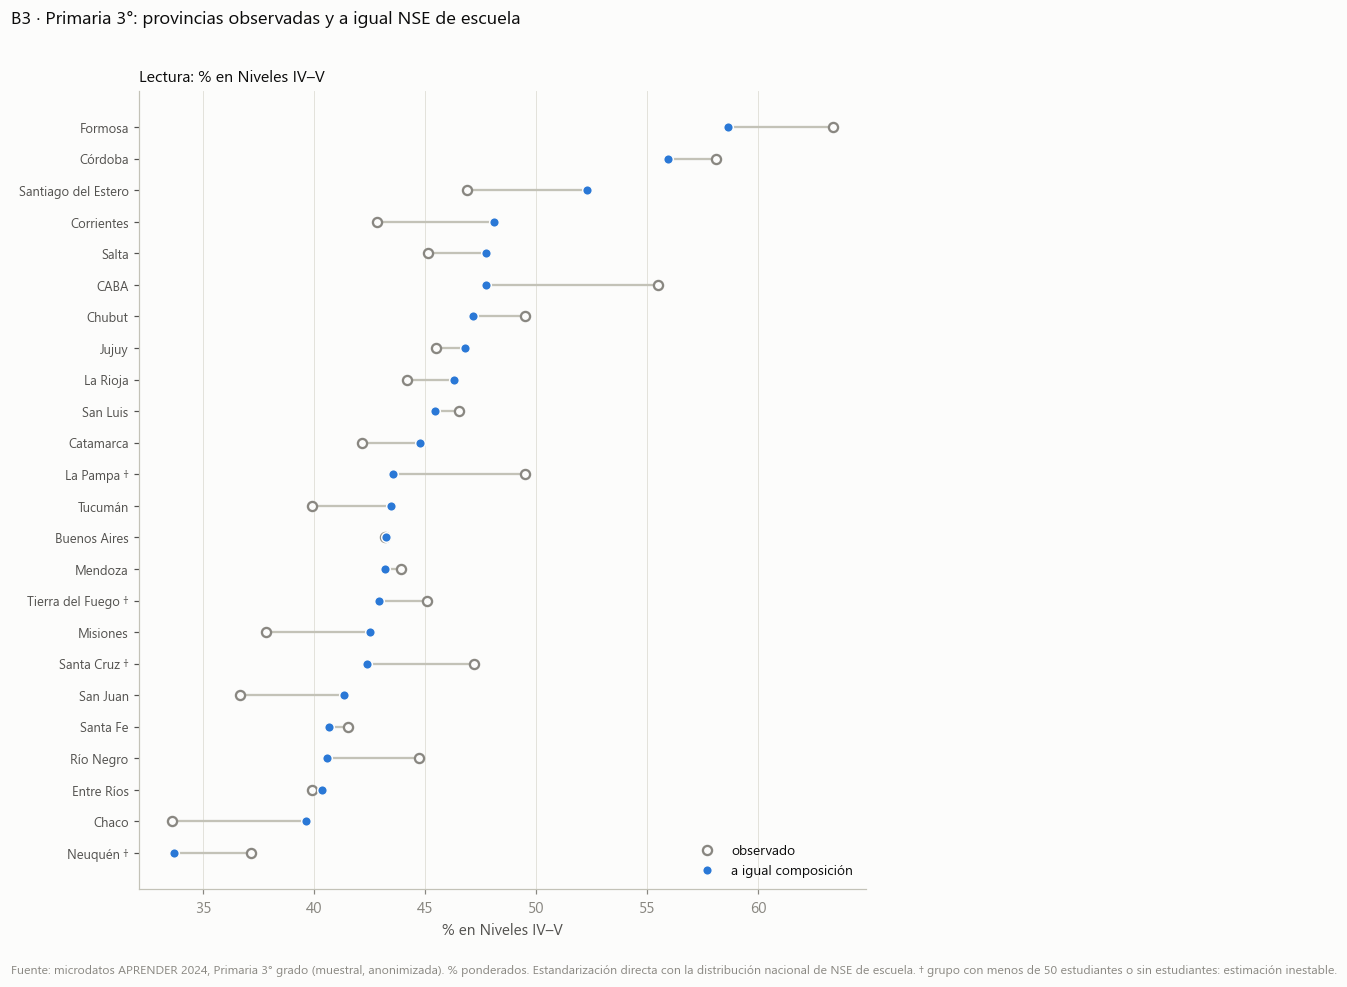

rango_pp                     desvio_pp  \
medida                observado a igual composición observado   
serie                                                           
Primaria 3° · Lectura      29.8                25.0       6.8   

                                          reducción del rango  
medida                a igual composición                   %  
serie                                                          
Primaria 3° · Lectura                 5.3                16.1

,observado,a igual composición,diferencia (pp),grupos sin estudiantes,celda mínima (n),n,rank observado,rank a igual composición
provincia,,,,,,,,
Formosa,63.4,58.6,-4.7,0,224.0,2325,1,1
Córdoba,58.1,55.9,-2.2,0,415.0,4799,2,2
Santiago del Estero,46.9,52.3,5.4,0,224.0,3308,7,3
Corrientes,42.8,48.1,5.3,0,392.0,3314,16,4
Salta,45.1,47.7,2.6,0,454.0,3528,10,5
CABA,55.5,47.7,-7.8,0,51.0,2962,3,6
Chubut,49.5,47.1,-2.3,0,98.0,2580,5,7
Jujuy,45.5,46.8,1.3,0,398.0,2778,9,8
La Rioja,44.2,46.3,2.1,0,104.0,2116,13,9


In [9]:
B3 = estandarizar(PRI, 'NSE_escuela', 'ldesemp', 'ponderL', ALTOS_P)
assert len(B3) == 24
fig, ax = plt.subplots(figsize=(8, 8.5))
dumbbell(ax, B3, 'Lectura: % en Niveles IV–V', '% en Niveles IV–V')
ax.legend(frameon=False, fontsize=9, loc='lower right')
fig.suptitle('B3 · Primaria 3°: provincias observadas y a igual NSE de escuela', x=0.01, ha='left', fontsize=12, y=1.01)
fig.tight_layout(); nota(fig, FUENTE_P + ' Estandarización directa con la distribución nacional de NSE de escuela. † grupo con menos de 50 estudiantes o sin estudiantes: estimación inestable.')
guardar(fig, 'B3_primaria_provincias_igual_nse'); plt.show()
B3_DISP = dispersion_provincial({'Primaria 3° · Lectura': B3})
display(B3_DISP.round(1))
display(B3.round(1))

---
## C · Lectura de resultados (corrida 2026-09-16)

**Control.** Los microdatos reproducen los agregados: Secundaria Lengua 56,9 % y Matemática 17,7 % Satisfactorio +
Avanzado; Primaria 3° Nivel IV 26,3 %; y los valores por provincia coinciden con la base agregada (p. ej. Formosa
Primaria 3°, Niveles IV–V: 63,4 % vs 63,6 %).

**1. Secundaria: el contexto del hogar separa mucho el desempeño (A1, A2).**
- Brecha entre la categoría más y la menos favorable (pp de Satisfactorio + Avanzado, Lengua / Matemática):
  - **libros** 38,5 / 27,3 (más de 50 vs menos de 6);
  - **repitencia en primaria** 31,3 / 14,6;
  - **edad** (17 o menos vs 19 o más) 25,2 / 12,4;
  - **educación de la madre** 23,5 / 18,9;
  - **computadora** 17,6 / 13,1;
  - **horas de estudio** 15,5 / 12,9;
  - **ámbito** urbano−rural 15,7 / 8,3;
  - **espacio para estudiar** 5,3 / 5,9.
- **Sexo:** las mujeres superan a los varones en Lengua (+4,3 pp) y los varones a las mujeres en Matemática (+7,6 pp).
- **Recursos acumulados:** con 0–1 de los 5 recursos del hogar, ≈ 45 % llega a Satisfactorio + Avanzado en Lengua y ≈ 8 %
  en Matemática; con los 5, 82 % y 46 %. El salto grande ocurre a partir de 3 recursos.

**2. La ventaja del sector privado se achica a igual contexto, pero no desaparece (A3).**
- Lengua: la brecha privado − estatal pasa de 22,3 pp a 16–20 pp a igual educación de la madre y a 12–19 pp a igual
  cantidad de recursos del hogar.
- Matemática: de 17,1 pp a 9–16 pp y a 7–14 pp.
- **Qué queda sin explicar:** estas variables son gruesas y no miden la segregación entre escuelas ni otros rasgos de las
  familias que eligen el sector privado. La brecha restante **no** es "efecto escuela".

**3. Provincias a igual composición de los hogares (A4): la composición explica ≈ 1/4 a 1/3 de las diferencias.**
- El rango entre provincias baja de 28,2 a 18,8 pp en Lengua (−33 %) y de 26,7 a 19,6 pp en Matemática (−27 %).
- CABA pierde ≈ 6 pp (su población es más educada) pero sigue primera; La Pampa y Córdoba siguen arriba.
- Santiago del Estero (+5,6 pp en Lengua), Formosa (+4,5), Chaco y San Juan (+4,1) y Tucumán (+3,8) ganan: parte de su
  resultado bajo es composición, aunque **siguen en la mitad inferior**. Mendoza sube del puesto 13 al 7 en Lengua.

**4. Primaria 3°: el nivel socioeconómico de la escuela y la trayectoria pesan más (B1).**
- % en Niveles IV–V:
  - **NSE de la escuela:** Bajo 32,0 % → Alto 66,7 % (+34,7 pp);
  - **no repitió vs repitió:** 48,4 % vs 18,4 %;
  - **sala de 3 vs sala de 5 o no asistió:** 51,1 % vs 36,2 %;
  - **la familia le pregunta qué hizo en la escuela:** 46,9 % vs 27,7 %;
  - **más de 20 libros:** +9,3 pp;
  - **la maestra le ayuda cuando algo sale mal:** +9,2 pp;
  - **sector privado:** +23,5 pp;
  - **nenas:** +4,4 pp.
- **Sin diferencia:** gusto por la escuela y edad.
- **Resultado a revisar:** quienes dicen que alguien de la familia les lee rinden **peor** (36,8 % vs 50,3 %), y pasa en todos
  los niveles de NSE (−8 a −13 pp). Una explicación posible es la **causalidad inversa**: las familias leen más a los chicos
  que todavía no leen solos. No se puede confirmar sin el cuestionario; tampoco se descarta un problema de etiquetas.
  Algo parecido con el celular: rinden mejor quienes usan el de un familiar (50,9 %) que quienes tienen uno propio (45,0 %).

**5. A igual NSE de la escuela (B2).**
- La ventaja del **jardín desde sala de 3** crece con el NSE: +1,6 pp en escuelas de NSE bajo y +16,4 pp en NSE alto.
  El jardín temprano solo se asocia con mejor lectura donde el resto del contexto acompaña, o bien la asistencia temprana
  en NSE alto refleja otros rasgos de esas familias.
- **Libros:** −6,2 pp en NSE bajo, +8,1 pp en medio alto. **Repitencia:** la brecha va de 17 a 41 pp y crece con el NSE.
- **Sector:** a igual NSE la brecha privado − estatal baja de 23,5 pp a entre −4,2 (NSE bajo) y +8,0 pp. En Primaria 3°,
  casi toda la ventaja del sector privado se explica por el NSE de sus escuelas.

**6. Provincias a igual NSE de escuela (B3): la composición explica poco en Primaria 3°.**
- El rango baja solo 16 % (29,8 → 25,0 pp).
- Formosa (63,4 %) sigue primera a igual NSE (58,6 %), también en la base agregada. Conviene contrastarlo con la cobertura
  de la muestra y la participación en esa provincia.
- Santiago del Estero sube del 7° al 3° puesto y Corrientes del 16° al 4°; CABA baja del 3° al 6°.
- La Pampa, Neuquén, Santa Cruz y Tierra del Fuego (†) tienen grupos con pocos casos: estimación inestable.

**Qué no se puede afirmar.** Es una foto 2024 de datos anonimizados: asociaciones entre variables del estudiante, no causas.
Las variables de contexto están muy correlacionadas entre sí (la estandarización controla solo las que se indican) y en
Secundaria rinden quienes llegaron al último año (quienes abandonaron no están).

---
## D · Descargar gráficos y tablas
Guarda las tablas en `microdatos_2024.xlsx` dentro de `graficos_microdatos/`, comprime la carpeta en un `.zip` y, en
**Colab**, **lo descarga**. Los `.sav` extraídos no se incluyen.

In [10]:
hojas = {'control_distribucion': pd.concat({'Secundaria ' + a: v for a, v in ctl_s.items()}, axis=1).round(3),
         'control_primaria': ctl_p.round(3).to_frame('% ponderado'),
         'A1_secundaria_contexto': A1.set_index(['variable', 'categoria', 'area']), 'A1_brechas': A1_BRECHAS.set_index(['variable', 'area']),
         'A2_recursos_hogar': A2, 'A3_sector_igual_contexto': A3.set_index(['area', 'igualando_por', 'estrato', 'sector']),
         'A3_brecha_sector': A3_BRECHA,
         'A4_prov_lengua': A4['Lengua'], 'A4_prov_matematica': A4['Matemática'],
         'A4_B3_dispersion_provincias': pd.concat([A4_DISP, B3_DISP]),
         'B1_primaria_contexto': B1.set_index(['variable', 'categoria']), 'B1_brechas': B1_BRECHAS.set_index(['variable', 'area']),
         'B2_igual_nse': B2.set_index(['variable', 'NSE_escuela', 'categoria']), 'B2_brecha_igual_nse': B2_BRECHA.set_index(['variable', 'comparación', 'NSE_escuela']),
         'B3_prov_igual_nse': B3}
ruta_xlsx = os.path.join(GRAF, 'microdatos_2024.xlsx')
with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as xw:
    for nombre, t in hojas.items():
        t = t.copy()
        num = t.select_dtypes('number').columns
        t[num] = t[num].round(3)
        t.to_excel(xw, sheet_name=nombre[:31])
print('Archivos a descargar:')
for n in sorted(os.listdir(GRAF)): print('  -', n)
zip_path = shutil.make_archive(os.path.join(os.path.dirname(GRAF), 'graficos_microdatos'), 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)
    print('Descargando el zip...')
else:
    print('Entorno local: los archivos quedan en', GRAF)

Archivos a descargar:
  - A1_secundaria_contexto.png
  - A2_secundaria_recursos_hogar.png
  - A3_secundaria_sector_igual_contexto.png
  - A4_secundaria_provincias_igual_composicion.png
  - B1_primaria_contexto.png
  - B2_primaria_igual_nse.png
  - B3_primaria_provincias_igual_nse.png
  - microdatos_2024.xlsx

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_microdatos.zip (2.0 MB)
Entorno local: los archivos quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_microdatos
